## Testing Other Models — Binary At-Risk, Fine-tuned @ T=180

Gộp **Fail** + **Withdrawn** thành **At-risk (1)**, **Pass → 0**. Chỉ dùng sinh viên **còn active tại T=180** (snapshot `prediction_point == 180`).

- **Models**: Logistic Regression, Random Forest, CatBoost, LightGBM
  - *SVM (RBF) được bỏ qua*: không khả thi trên dữ liệu lớn.
- **Fine-tune (Optuna) cho từng model** — giống recipe các notebook cũ:
  - Tune đồng thời: hyperparameter của model + **SMOTE ratio** (At-risk) + **class_weight** (At-risk).
  - Tối ưu **F1-score At-risk** (pos_label=1) qua **StratifiedKFold** (3-fold).
- **Scaling**: chỉ **Logistic Regression** được scale (`StandardScaler` fit trên train-fold để tránh leakage); model cây bất biến với scaling.
- **Metric**: Confusion matrix, classification report, ROC-AUC cho từng model + bảng tổng hợp precision / recall / f1 (lớp **At-risk**), accuracy, ROC-AUC.

In [27]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import RANDOM_SEED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score,
)

TARGET_NAMES = ['Pass', 'At-risk']
CLASSES = [0, 1]

In [28]:
data_dir = Path('../data/processed')

PREDICTION_POINT = 180  # chỉ giữ sinh viên còn active tại T=180

X_train_all = pd.read_parquet(data_dir / 'X_train.parquet')
X_test_all  = pd.read_parquet(data_dir / 'X_test.parquet')
y_train_all = pd.read_parquet(data_dir / 'y_train.parquet').squeeze()
y_test_all  = pd.read_parquet(data_dir / 'y_test.parquet').squeeze()
train_meta  = pd.read_parquet(data_dir / 'train_meta.parquet')
test_meta   = pd.read_parquet(data_dir / 'test_meta.parquet')

# Lọc về snapshot T=180 (sinh viên withdraw <= 180 ngày đã bị loại khỏi snapshot này)
mask_tr = (train_meta['prediction_point'] == PREDICTION_POINT).values
mask_te = (test_meta['prediction_point'] == PREDICTION_POINT).values

X_train = X_train_all[mask_tr].reset_index(drop=True).fillna(0)
X_test  = X_test_all[mask_te].reset_index(drop=True).fillna(0)
y_train = y_train_all[mask_tr].reset_index(drop=True)
y_test  = y_test_all[mask_te].reset_index(drop=True)

# Gộp Fail (0) + Withdrawn (2) -> At-risk (1); Pass (1) -> 0
LABEL_MAP = {0: 1, 1: 0, 2: 1}
y_train = y_train.map(LABEL_MAP)
y_test  = y_test.map(LABEL_MAP)

print('Prediction point:', PREDICTION_POINT)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Features:', list(X_train.columns))
print('Train dist:', y_train.value_counts().rename({0: 'Pass', 1: 'At-risk'}).to_dict())
print('Test  dist:', y_test.value_counts().rename({0: 'Pass', 1: 'At-risk'}).to_dict())

Prediction point: 180
X_train: (16786, 15) | X_test: (4215, 15)
Features: ['highest_education', 'disability', 'num_of_prev_attempts', 'studied_credits', 'total_clicks_filled', 'active_weeks_filled', 'avg_weekly_clicks_filled', 'num_due', 'num_submitted_filled', 'avg_score_filled', 'num_failed_filled', 'avg_days_early_filled', 'no_submission_despite_due', 'imd_band_filled', 'imd_missing']
Train dist: {'Pass': 11067, 'At-risk': 5719}
Test  dist: {'Pass': 2804, 'At-risk': 1411}


### Cấu hình model + search space

Mỗi model có: `needs_scaling`, hàm `suggest` (search space hyperparameter cho Optuna), và hàm `make` (tạo estimator với class_weight At-risk). SMOTE ratio và class_weight được tune chung cho mọi model.

In [29]:
N_TRIALS = 30  # số trial Optuna mỗi model (giảm nếu muốn chạy nhanh hơn)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)


def safe_smote_bin(X, y, ratio_at_risk):
    """Oversample At-risk: new_count = int((1 + ratio) * N_current), ratio ∈ [0.1, 0.9]."""
    y_arr = np.asarray(y)
    n_at_risk = int((y_arr == 1).sum())
    target = {1: int((1 + ratio_at_risk) * n_at_risk)}
    k = max(1, min(5, n_at_risk - 1))
    sm = SMOTE(sampling_strategy=target, random_state=RANDOM_SEED, k_neighbors=k)
    return sm.fit_resample(np.asarray(X), y_arr)


# --- Search space + estimator factory cho từng model ---
def suggest_logreg(trial):
    return {'C': trial.suggest_float('C', 1e-3, 1e2, log=True)}

def make_logreg(params, w):
    return LogisticRegression(C=params['C'], max_iter=1000,
                              class_weight={0: 1.0, 1: w}, random_state=RANDOM_SEED)


def suggest_rf(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400),
        'max_depth':        trial.suggest_int('max_depth', 4, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

def make_rf(params, w):
    return RandomForestClassifier(**params, class_weight={0: 1.0, 1: w},
                                  random_state=RANDOM_SEED, n_jobs=-1)


def suggest_cat(trial):
    return {
        'iterations':    trial.suggest_int('iterations', 200, 600),
        'depth':         trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
    }

def make_cat(params, w):
    return CatBoostClassifier(**params, class_weights=[1.0, w],
                              random_state=RANDOM_SEED, verbose=0)


def suggest_lgbm(trial):
    return {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 63),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }

def make_lgbm(params, w):
    return LGBMClassifier(**params, class_weight={0: 1.0, 1: w},
                          random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)


MODEL_CONFIGS = {
    'Logistic Regression': dict(needs_scaling=True,  suggest=suggest_logreg, make=make_logreg),
    'Random Forest':       dict(needs_scaling=False, suggest=suggest_rf,     make=make_rf),
    'CatBoost':            dict(needs_scaling=False, suggest=suggest_cat,    make=make_cat),
    'LightGBM':            dict(needs_scaling=False, suggest=suggest_lgbm,   make=make_lgbm),
}
list(MODEL_CONFIGS)

['Logistic Regression', 'Random Forest', 'CatBoost', 'LightGBM']

### Fine-tune & đánh giá từng model

Với mỗi model: Optuna (`N_TRIALS` trials) tune hyperparameter + SMOTE ratio + class_weight, tối ưu F1 At-risk qua 3-fold CV → retrain best params trên full train → đánh giá test (confusion matrix + report + ROC-AUC).

> ⚠️ Chạy khá nặng (4 model × Optuna × 3-fold, có SMOTE mỗi fold) — chủ yếu ở CatBoost & Random Forest. Giảm `N_TRIALS` ở cell trên nếu cần nhanh hơn.


############################################################
  FINE-TUNE: Logistic Regression
############################################################


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7918
SMOTE → At-risk: +0.90x | class_weight At-risk: 1.01
              precision    recall  f1-score   support

        Pass      0.896     0.868     0.882      2804
     At-risk      0.753     0.799     0.775      1411

    accuracy                          0.845      4215
   macro avg      0.824     0.834     0.829      4215
weighted avg      0.848     0.845     0.846      4215



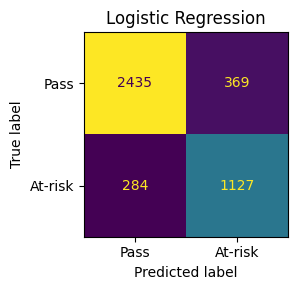

ROC-AUC: 0.9163

############################################################
  FINE-TUNE: Random Forest
############################################################


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7986
SMOTE → At-risk: +0.51x | class_weight At-risk: 1.10
              precision    recall  f1-score   support

        Pass      0.888     0.918     0.903      2804
     At-risk      0.825     0.769     0.796      1411

    accuracy                          0.868      4215
   macro avg      0.856     0.843     0.849      4215
weighted avg      0.867     0.868     0.867      4215



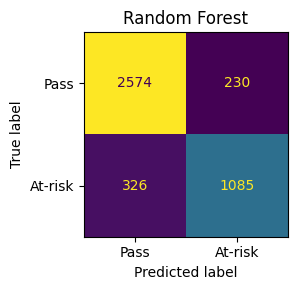

ROC-AUC: 0.9248

############################################################
  FINE-TUNE: CatBoost
############################################################


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8074
SMOTE → At-risk: +0.62x | class_weight At-risk: 1.04
              precision    recall  f1-score   support

        Pass      0.884     0.931     0.907      2804
     At-risk      0.846     0.758     0.800      1411

    accuracy                          0.873      4215
   macro avg      0.865     0.844     0.853      4215
weighted avg      0.872     0.873     0.871      4215



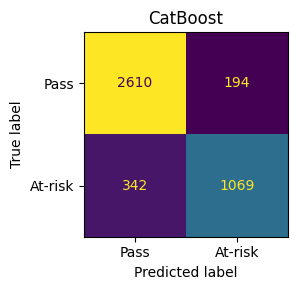

ROC-AUC: 0.9304

############################################################
  FINE-TUNE: LightGBM
############################################################


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8043
SMOTE → At-risk: +0.10x | class_weight At-risk: 1.46
              precision    recall  f1-score   support

        Pass      0.899     0.904     0.902      2804
     At-risk      0.808     0.797     0.802      1411

    accuracy                          0.869      4215
   macro avg      0.853     0.851     0.852      4215
weighted avg      0.868     0.869     0.868      4215



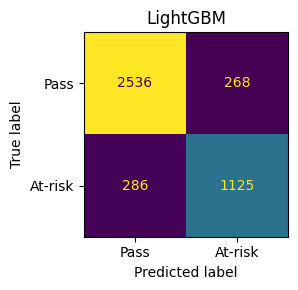

ROC-AUC: 0.9292


In [30]:
def tune_and_evaluate(name, cfg, X_tr, y_tr, X_te, y_te, n_trials=N_TRIALS, plot_cm=True):
    needs_scaling = cfg['needs_scaling']
    Xtr = np.asarray(X_tr); Xte = np.asarray(X_te)
    ytr = np.asarray(y_tr); yte = np.asarray(y_te)

    def objective(trial):
        params = cfg['suggest'](trial)
        ratio  = trial.suggest_float('smote_ratio_at_risk', 0.1, 0.9)
        w      = trial.suggest_float('w_at_risk', 1.0, 8.0)

        scores = []
        for tr_idx, val_idx in cv.split(Xtr, ytr):
            Xf_tr, yf_tr = Xtr[tr_idx], ytr[tr_idx]
            Xf_val, yf_val = Xtr[val_idx], ytr[val_idx]

            if needs_scaling:  # fit scaler chỉ trên train-fold (tránh leakage)
                sc = StandardScaler().fit(Xf_tr)
                Xf_tr, Xf_val = sc.transform(Xf_tr), sc.transform(Xf_val)

            Xf_sm, yf_sm = safe_smote_bin(Xf_tr, yf_tr, ratio)
            m = cfg['make'](params, w)
            m.fit(Xf_sm, yf_sm)
            scores.append(f1_score(yf_val, m.predict(Xf_val), pos_label=1, zero_division=0))
        return float(np.mean(scores))

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    bp = study.best_params
    model_params = {k: v for k, v in bp.items()
                    if k not in ('smote_ratio_at_risk', 'w_at_risk')}
    best_ratio, best_w = bp['smote_ratio_at_risk'], bp['w_at_risk']
    print(f'Best F1 At-risk CV: {study.best_value:.4f}')
    print(f'SMOTE → At-risk: +{best_ratio:.2f}x | class_weight At-risk: {best_w:.2f}')

    # Retrain best params trên full train
    if needs_scaling:
        scaler = StandardScaler().fit(Xtr)
        Xtr_f, Xte_f = scaler.transform(Xtr), scaler.transform(Xte)
    else:
        scaler, Xtr_f, Xte_f = None, Xtr, Xte
    X_sm, y_sm = safe_smote_bin(Xtr_f, ytr, best_ratio)
    final = cfg['make'](model_params, best_w)
    final.fit(X_sm, y_sm)

    y_pred  = final.predict(Xte_f)
    y_proba = final.predict_proba(Xte_f)[:, 1]

    print(classification_report(yte, y_pred, target_names=TARGET_NAMES, digits=3))
    if plot_cm:
        cm = confusion_matrix(yte, y_pred, labels=CLASSES)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
        ax.set_title(name)
        plt.tight_layout()
        plt.show()

    roc_auc = roc_auc_score(yte, y_proba)
    print(f'ROC-AUC: {roc_auc:.4f}')

    row = {
        'model':     name,
        'accuracy':  round(accuracy_score(yte, y_pred), 4),
        'precision': round(precision_score(yte, y_pred, pos_label=1, zero_division=0), 4),
        'recall':    round(recall_score(yte, y_pred, pos_label=1, zero_division=0), 4),
        'f1':        round(f1_score(yte, y_pred, pos_label=1, zero_division=0), 4),
        'roc_auc':   round(roc_auc, 4),
    }
    return row, (scaler, final)


trained_models = {}
metrics_rows   = []

for name, cfg in MODEL_CONFIGS.items():
    print(f'\n{"#"*60}\n  FINE-TUNE: {name}\n{"#"*60}')
    row, model_obj = tune_and_evaluate(name, cfg, X_train, y_train, X_test, y_test)
    metrics_rows.append(row)
    trained_models[name] = model_obj  # (scaler, fitted_model)

### Bảng so sánh các model

precision / recall / f1 tính cho lớp **At-risk** (pos_label=1); ROC-AUC là binary. Ô tô đậm = giá trị tốt nhất mỗi cột.

In [31]:
comparison_df = (
    pd.DataFrame(metrics_rows)
    .set_index('model')
    .sort_values('f1', ascending=False)
)
print('--- So sánh model ---')
print(comparison_df)


def style_max(df):
    """Tô chỉ số cao nhất mỗi cột: nền trắng, chữ đen in đậm."""
    return (
        df.style
        .apply(lambda s: ['background-color: white; color: black; font-weight: bold'
                          if v == s.max() else '' for v in s], axis=0)
        .format('{:.4f}')
    )


style_max(comparison_df)

--- So sánh model ---
                     accuracy  precision  recall      f1  roc_auc
model                                                            
LightGBM               0.8686     0.8076  0.7973  0.8024   0.9292
CatBoost               0.8728     0.8464  0.7576  0.7996   0.9304
Random Forest          0.8681     0.8251  0.7690  0.7960   0.9248
Logistic Regression    0.8451     0.7533  0.7987  0.7754   0.9163


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LightGBM,0.8686,0.8076,0.7973,0.8024,0.9292
CatBoost,0.8728,0.8464,0.7576,0.7996,0.9304
Random Forest,0.8681,0.8251,0.7690,0.7960,0.9248
Logistic Regression,0.8451,0.7533,0.7987,0.7754,0.9163


---

## Feature Importance (native mỗi model)

Mỗi thuật toán dùng định nghĩa importance riêng của nó — **không quy về cùng đơn vị**:
- **Logistic Regression**: `|coef|` (hệ số trên dữ liệu đã scale → so sánh được giữa các feature trong cùng model).
- **Random Forest**: impurity-based (`feature_importances_`, Gini).
- **CatBoost**: PredictionValuesChange (`feature_importances_`).
- **LightGBM**: số lần feature được dùng để split (`feature_importances_`, type='split').

Vì khác đơn vị nên chỉ đọc **thứ hạng feature trong từng model**, đừng so sánh trực tiếp con số giữa các model.

In [32]:
FEATURE_NAMES = list(X_train.columns)


def get_native_importance(model):
    """|coef| cho model tuyến tính, feature_importances_ cho model cây."""
    if hasattr(model, 'feature_importances_'):
        return np.asarray(model.feature_importances_, dtype=float)
    if hasattr(model, 'coef_'):
        return np.abs(np.ravel(model.coef_))
    raise ValueError(f'{type(model).__name__} không có feature importance')


importance_by_model = {}
for name, (scaler, model) in trained_models.items():
    importance_by_model[name] = pd.Series(
        get_native_importance(model), index=FEATURE_NAMES, name=name,
    )

# Bảng tham chiếu: importance thô (đơn vị khác nhau giữa các model)
importance_df = pd.DataFrame(importance_by_model)
print('--- Feature importance (giá trị thô, KHÔNG so sánh chéo) ---')
importance_df

--- Feature importance (giá trị thô, KHÔNG so sánh chéo) ---


,Logistic Regression,Random Forest,CatBoost,LightGBM
highest_education,0.179326,0.031637,19.779582,182.0
disability,0.005571,0.001062,1.141306,25.0
num_of_prev_attempts,0.035709,0.007782,6.753713,111.0
studied_credits,0.001878,0.003181,1.137575,138.0
total_clicks_filled,2.412591,0.091875,2.302961,387.0
active_weeks_filled,0.115759,0.180318,6.711482,406.0
avg_weekly_clicks_filled,2.213962,0.027420,2.021308,398.0
num_due,1.859177,0.037563,15.567813,326.0
num_submitted_filled,2.470197,0.307003,22.237590,417.0
avg_score_filled,1.794983,0.186610,9.605888,630.0


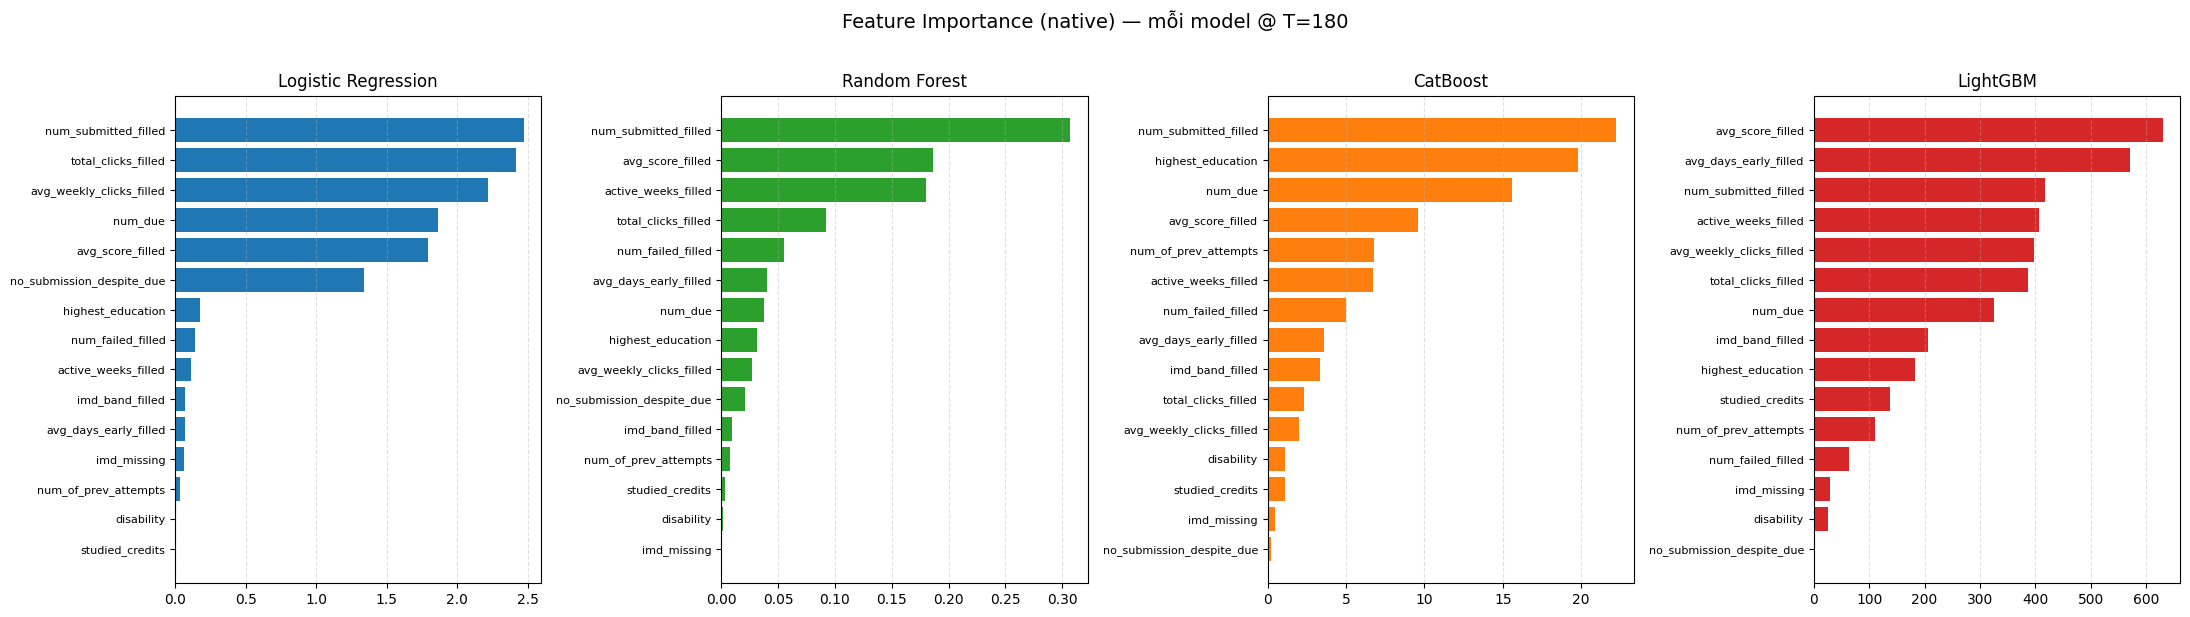

--- Thứ hạng feature theo từng model (1 = quan trọng nhất) ---


,Logistic Regression,Random Forest,CatBoost,LightGBM,mean_rank
num_submitted_filled,1,1,1,3,1.50
avg_score_filled,5,2,4,1,3.00
num_due,4,7,3,7,5.25
total_clicks_filled,2,4,10,6,5.50
active_weeks_filled,9,3,6,4,5.50
highest_education,7,8,2,9,6.50
avg_days_early_filled,11,6,8,2,6.75
avg_weekly_clicks_filled,3,9,11,5,7.00
num_failed_filled,8,5,7,12,8.00
imd_band_filled,10,11,9,8,9.50


In [33]:
colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

fig, axes = plt.subplots(1, len(importance_by_model), figsize=(22, 6), sharey=False)

for ax, color, (name, s) in zip(axes, colors, importance_by_model.items()):
    s_sorted = s.sort_values()
    ax.barh(s_sorted.index, s_sorted.values, color=color)
    ax.set_title(name, fontsize=12)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Feature Importance (native) — mỗi model @ T=180', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Thứ hạng feature mỗi model (1 = quan trọng nhất) + hạng trung bình
ranks = pd.DataFrame(
    {name: s.rank(ascending=False).astype(int) for name, s in importance_by_model.items()},
    index=FEATURE_NAMES,
)
ranks['mean_rank'] = ranks.mean(axis=1).round(2)
ranks = ranks.sort_values('mean_rank')
print('--- Thứ hạng feature theo từng model (1 = quan trọng nhất) ---')
ranks

---

## Train lại với Top-10 & Top-5 features

Chọn các feature có `mean_rank` tốt nhất (quan trọng xuyên suốt 4 model) rồi chạy lại **đúng pipeline fine-tune** (Optuna + SMOTE + class_weight, tối ưu F1 At-risk) cho cả 4 model trên **hai bộ feature rút gọn cùng lúc: Top-10 và Top-5**. So sánh với bản full-feature để xem hiệu suất có **ổn định** không khi cắt bớt feature.

Confusion matrix của mọi tổ hợp (feature-set × model) được gom thành **lưới subplot** (2 hàng × 4 cột) để so sánh trực tiếp.

> ⚠️ Cell train chạy nặng: 2 bộ feature × 4 model × Optuna × 3-fold (SMOTE mỗi fold).

In [34]:
from IPython.display import display

feature_sets = {
    'Top-10': list(ranks.index[:10]),
    'Top-5':  list(ranks.index[:5]),
}

trained_models_by_set = {}
comparison_by_set      = {}

for set_label, feats in feature_sets.items():
    print(f'\n{"="*60}\n  FEATURE SET: {set_label}  ({len(feats)} features)\n{"="*60}')
    for i, f in enumerate(feats, 1):
        print(f'  {i:2d}. {f}')

    X_tr_set, X_te_set = X_train[feats], X_test[feats]
    rows, models = [], {}
    for name, cfg in MODEL_CONFIGS.items():
        print(f'\n--- FINE-TUNE ({set_label}): {name} ---')
        row, model_obj = tune_and_evaluate(
            name, cfg, X_tr_set, y_train, X_te_set, y_test, plot_cm=False,
        )
        rows.append(row)
        models[name] = model_obj
    trained_models_by_set[set_label] = models
    comparison_by_set[set_label] = (
        pd.DataFrame(rows).set_index('model').sort_values('f1', ascending=False)
    )

# Giữ tên biến cũ để các cell phía sau (so sánh, SHAP) dùng lại được
trained_models_top  = trained_models_by_set['Top-10']
trained_models_top5 = trained_models_by_set['Top-5']
comparison_top_df   = comparison_by_set['Top-10']
comparison_top5_df  = comparison_by_set['Top-5']

top10, top5 = feature_sets['Top-10'], feature_sets['Top-5']
X_train_top,  X_test_top  = X_train[top10], X_test[top10]
X_train_top5, X_test_top5 = X_train[top5],  X_test[top5]

print('\n--- So sánh model (Top-10 features) ---')
display(style_max(comparison_top_df))
print('--- So sánh model (Top-5 features) ---')
display(style_max(comparison_top5_df))


  FEATURE SET: Top-10  (10 features)
   1. num_submitted_filled
   2. avg_score_filled
   3. num_due
   4. total_clicks_filled
   5. active_weeks_filled
   6. highest_education
   7. avg_days_early_filled
   8. avg_weekly_clicks_filled
   9. num_failed_filled
  10. imd_band_filled

--- FINE-TUNE (Top-10): Logistic Regression ---


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7927
SMOTE → At-risk: +0.55x | class_weight At-risk: 1.05
              precision    recall  f1-score   support

        Pass      0.886     0.895     0.891      2804
     At-risk      0.787     0.771     0.779      1411

    accuracy                          0.854      4215
   macro avg      0.837     0.833     0.835      4215
weighted avg      0.853     0.854     0.853      4215

ROC-AUC: 0.9157

--- FINE-TUNE (Top-10): Random Forest ---


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8008
SMOTE → At-risk: +0.50x | class_weight At-risk: 1.27
              precision    recall  f1-score   support

        Pass      0.896     0.898     0.897      2804
     At-risk      0.797     0.794     0.795      1411

    accuracy                          0.863      4215
   macro avg      0.846     0.846     0.846      4215
weighted avg      0.863     0.863     0.863      4215

ROC-AUC: 0.9260

--- FINE-TUNE (Top-10): CatBoost ---


...

  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8043
SMOTE → At-risk: +0.10x | class_weight At-risk: 1.46
              precision    recall  f1-score   support

        Pass      0.897     0.897     0.897      2804
     At-risk      0.795     0.794     0.795      1411

    accuracy                          0.863      4215
   macro avg      0.846     0.846     0.846      4215
weighted avg      0.863     0.863     0.863      4215

ROC-AUC: 0.9286

--- So sánh model (Top-10 features) ---


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LightGBM,0.8655,0.7972,0.8023,0.7997,0.9304
CatBoost,0.8614,0.7762,0.8235,0.7992,0.9303
Random Forest,0.8631,0.7966,0.7938,0.7952,0.9260
Logistic Regression,0.8536,0.7873,0.7711,0.7791,0.9157


--- So sánh model (Top-5 features) ---


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Random Forest,0.8700,0.8116,0.7966,0.8040,0.9279
CatBoost,0.8667,0.7979,0.8058,0.8018,0.9302
LightGBM,0.8626,0.7950,0.7945,0.7948,0.9286
Logistic Regression,0.8529,0.7876,0.7675,0.7775,0.9148


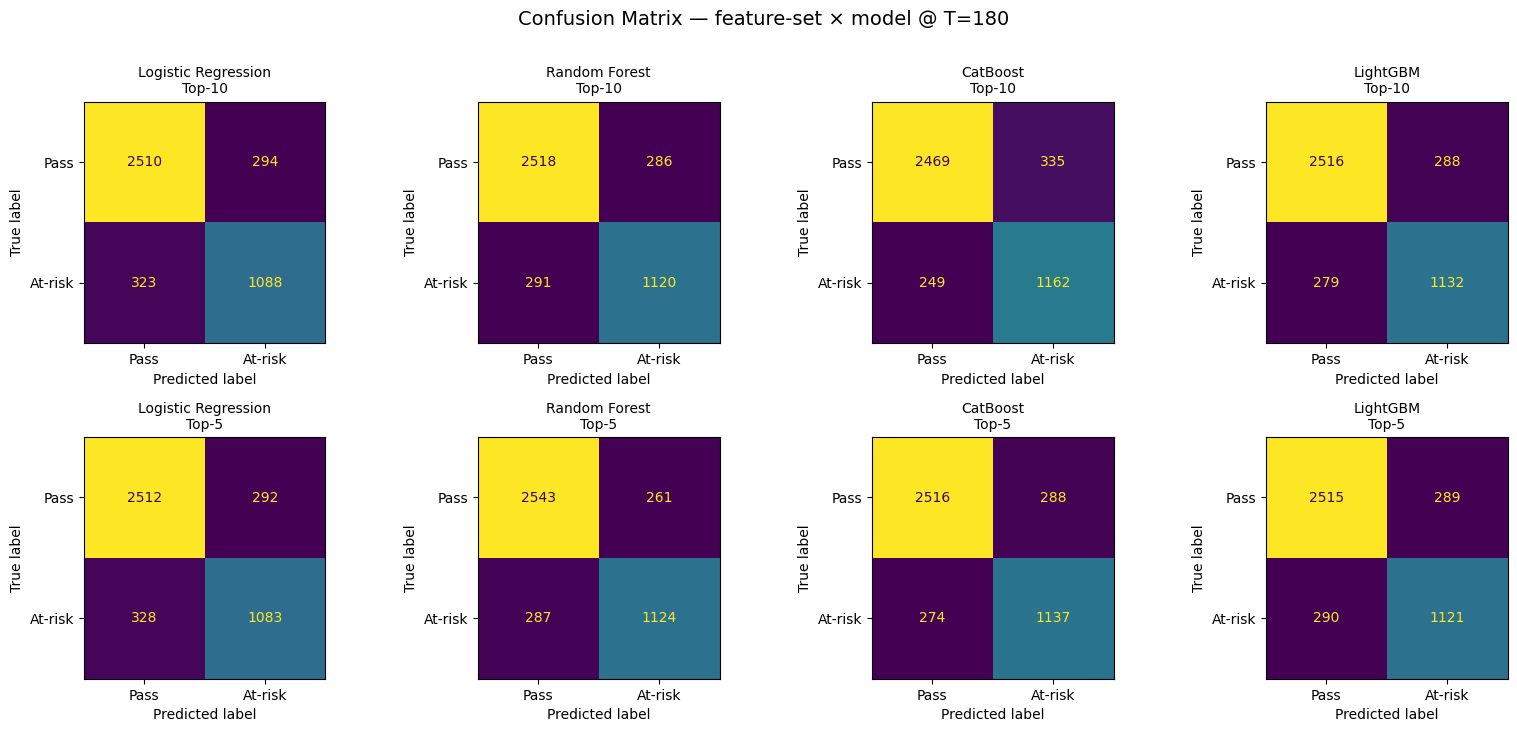

In [35]:
# Confusion matrix: mọi (feature-set × model) gom chung 1 lưới subplot để so sánh
model_order = list(MODEL_CONFIGS)
set_order   = list(feature_sets)

fig, axes = plt.subplots(
    len(set_order), len(model_order),
    figsize=(4 * len(model_order), 3.6 * len(set_order)),
)

for r, set_label in enumerate(set_order):
    Xte = np.asarray(X_test[feature_sets[set_label]])
    for c, name in enumerate(model_order):
        scaler, model = trained_models_by_set[set_label][name]
        X_in   = scaler.transform(Xte) if scaler is not None else Xte
        y_pred = model.predict(X_in)
        cm     = confusion_matrix(y_test, y_pred, labels=CLASSES)
        ax = axes[r, c]
        ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
        ax.set_title(f'{name}\n{set_label}', fontsize=10)

plt.suptitle('Confusion Matrix — feature-set × model @ T=180', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

--- Full(15) vs Top-10 vs Top-5 ---
                    Full(15)                                     Top-10  \
                    accuracy precision  recall      f1 roc_auc accuracy   
model                                                                     
Logistic Regression   0.8451    0.7533  0.7987  0.7754  0.9163   0.8536   
Random Forest         0.8681    0.8251  0.7690  0.7960  0.9248   0.8631   
CatBoost              0.8728    0.8464  0.7576  0.7996  0.9304   0.8614   
LightGBM              0.8686    0.8076  0.7973  0.8024  0.9292   0.8655   

                                                         Top-5            \
                    precision  recall      f1 roc_auc accuracy precision   
model                                                                      
Logistic Regression    0.7873  0.7711  0.7791  0.9157   0.8529    0.7876   
Random Forest          0.7966  0.7938  0.7952  0.9260   0.8700    0.8116   
CatBoost               0.7762  0.8235  0.7992  0.9303   0.

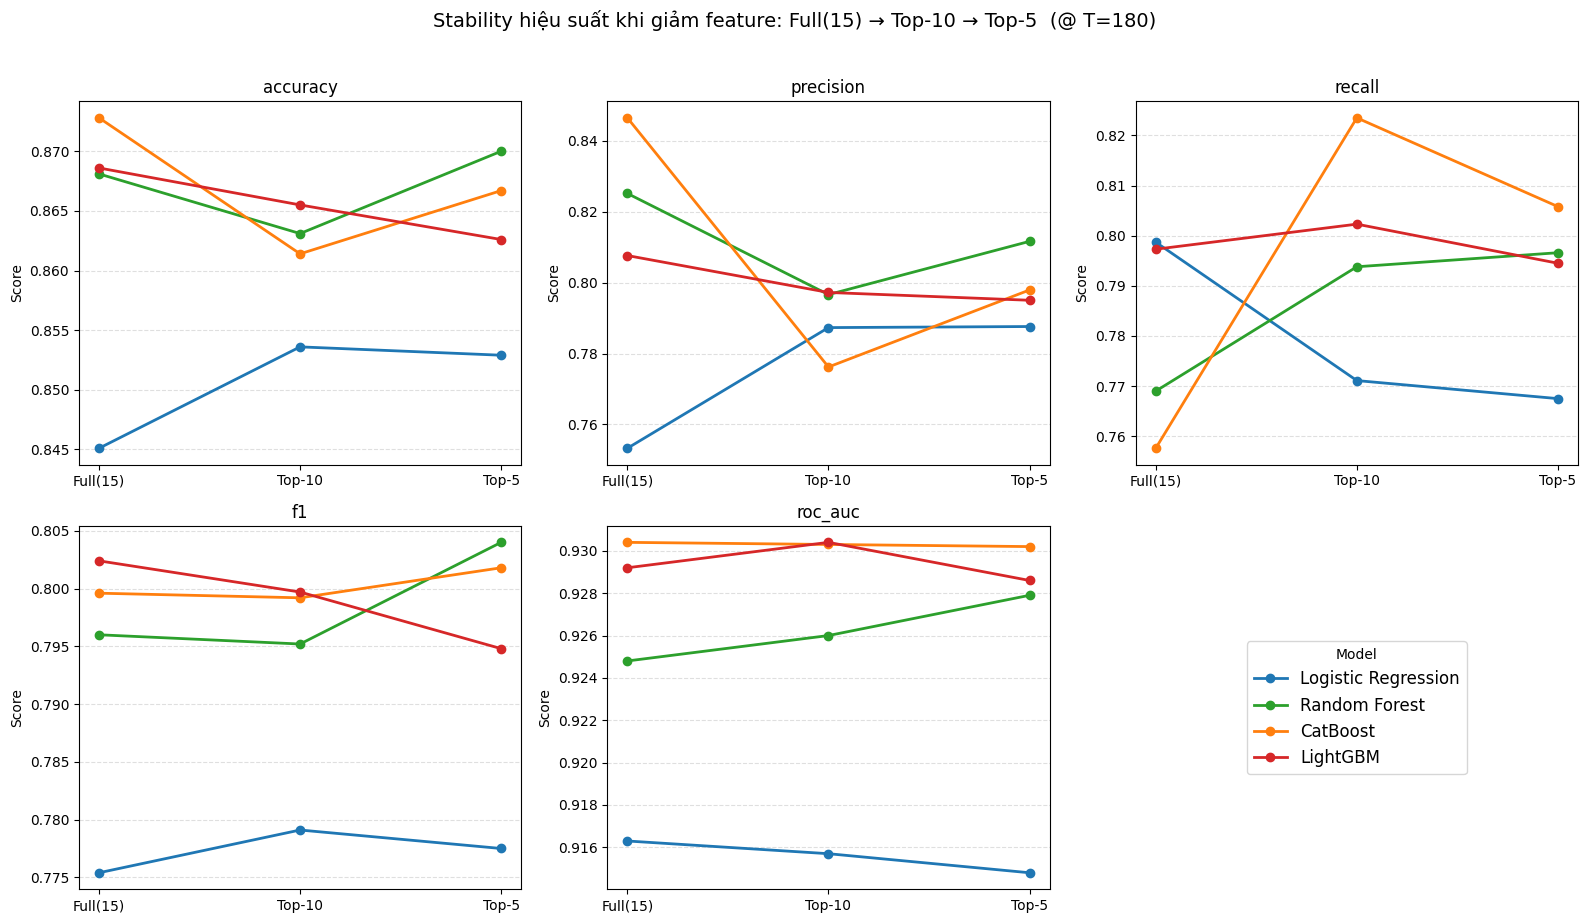

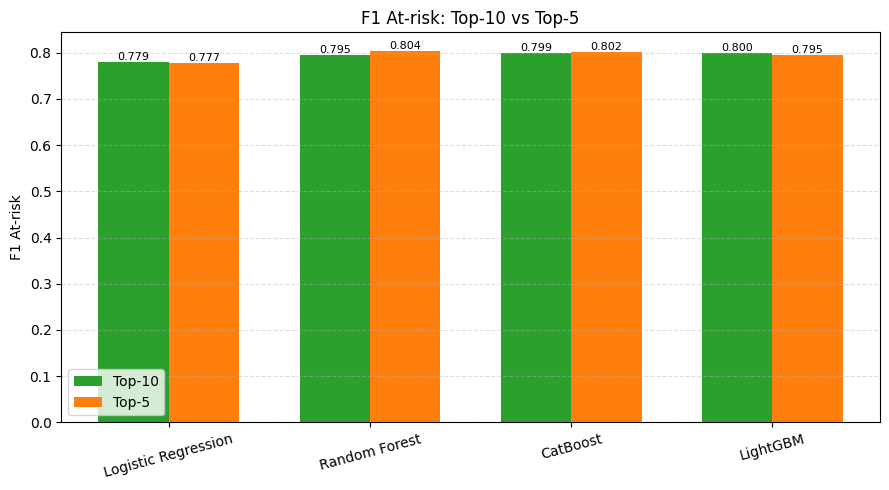

In [36]:
model_order = list(MODEL_CONFIGS)
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

full = comparison_df.reindex(model_order)
t10  = comparison_top_df.reindex(model_order)
t5   = comparison_top5_df.reindex(model_order)

# --- Bảng tổng hợp 3 feature-set ---
combined3 = pd.concat({'Full(15)': full, 'Top-10': t10, 'Top-5': t5}, axis=1)
print('--- Full(15) vs Top-10 vs Top-5 ---')
print(combined3)
print('\nΔ (Top-5 − Top-10):')
print((t5 - t10).round(4))

# --- Trực quan hóa: mỗi metric 1 subplot, x = feature-set, line per model ---
xsets = ['Full(15)', 'Top-10', 'Top-5']
data  = {'Full(15)': full, 'Top-10': t10, 'Top-5': t5}
mcolors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, metric in zip(axes, metrics):
    for name, c in zip(model_order, mcolors):
        ys = [data[s].loc[name, metric] for s in xsets]
        ax.plot(xsets, ys, marker='o', linewidth=2, color=c, label=name)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel('Score')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# ô thứ 6 dùng làm legend
axes[-1].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc='center', fontsize=12, title='Model')

plt.suptitle('Stability hiệu suất khi giảm feature: Full(15) → Top-10 → Top-5  (@ T=180)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Bar chart riêng cho F1 At-risk (so sánh trực tiếp Top-10 vs Top-5) ---
x = np.arange(len(model_order))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, t10['f1'].values, w, label='Top-10', color='tab:green')
ax.bar(x + w/2, t5['f1'].values,  w, label='Top-5',  color='tab:orange')
for i, (a, b) in enumerate(zip(t10['f1'].values, t5['f1'].values)):
    ax.text(i - w/2, a + 0.005, f'{a:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15)
ax.set_ylabel('F1 At-risk')
ax.set_title('F1 At-risk: Top-10 vs Top-5')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---

## SHAP — Explainable AI (model tốt nhất, cả 3 feature set)

Chọn **model tốt nhất theo F1 At-risk** (full-feature), giải thích bằng SHAP trên **cả 3 bộ feature** (Full / Top-10 / Top-5) để xem feature nào đẩy dự đoán về **At-risk**.

- Tree models (RF/CatBoost/LightGBM) → `TreeExplainer`; Logistic Regression → `LinearExplainer` (trên dữ liệu đã scale).
- **Beeswarm**: mỗi điểm là 1 sinh viên; màu = giá trị feature; trục x = SHAP value (>0 đẩy về **At-risk**, <0 đẩy về **Pass**).
- **Bar**: mean(|SHAP|) — độ quan trọng tổng thể của feature.
- Chạy trên mẫu test (`SHAP_SAMPLE`) cho nhanh & dễ đọc.

In [37]:
import shap

SHAP_SAMPLE = 2000  # số mẫu test dùng cho SHAP (giảm nếu chậm)
BEST_MODEL  = comparison_df['f1'].idxmax()
print(f'Model tốt nhất theo F1 At-risk: {BEST_MODEL}')


def shap_explain(set_label, models_dict, X_te_set, feat_names):
    scaler, model = models_dict[BEST_MODEL]

    Xs = X_te_set
    if len(Xs) > SHAP_SAMPLE:
        Xs = Xs.sample(SHAP_SAMPLE, random_state=RANDOM_SEED)

    if scaler is not None:  # LogReg → SHAP trên dữ liệu đã scale
        X_input = pd.DataFrame(scaler.transform(Xs), columns=feat_names, index=Xs.index)
        explainer = shap.LinearExplainer(model, X_input)
    else:                   # tree models
        X_input = Xs
        explainer = shap.TreeExplainer(model)

    sv = explainer(X_input)
    if sv.values.ndim == 3:        # phòng trường hợp trả (n, feat, 2) → lấy lớp At-risk
        sv = sv[..., 1]

    print(f'\n{"="*55}\n  SHAP — {BEST_MODEL}  |  {set_label} ({len(feat_names)} features)\n{"="*55}')
    shap.plots.beeswarm(sv, max_display=len(feat_names), show=False)
    plt.title(f'SHAP beeswarm — {set_label}', fontsize=12)
    plt.show()
    shap.plots.bar(sv, max_display=len(feat_names), show=False)
    plt.title(f'SHAP mean|value| — {set_label}', fontsize=12)
    plt.show()
    return sv

Model tốt nhất theo F1 At-risk: LightGBM



  SHAP — LightGBM  |  Full (15) (15 features)


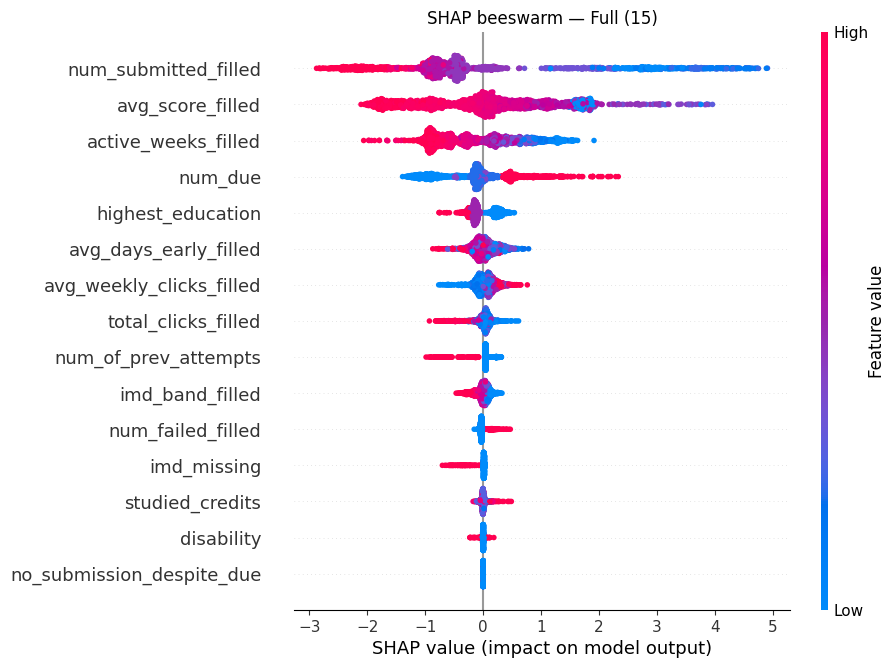

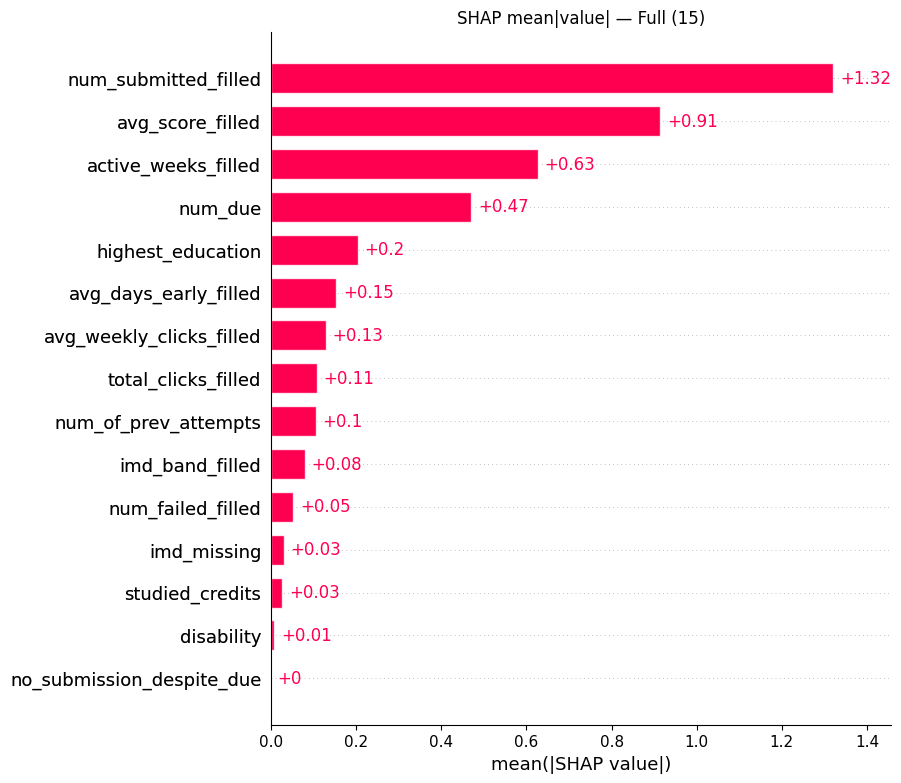


  SHAP — LightGBM  |  Top-10 (10 features)


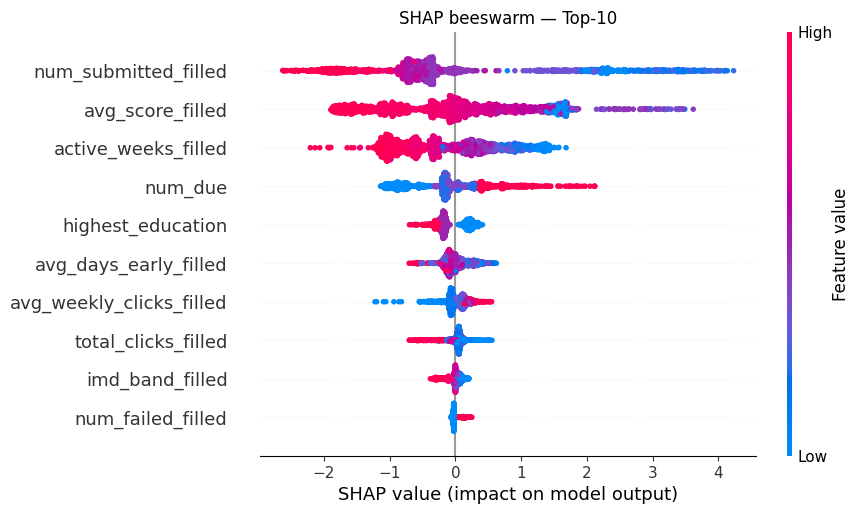

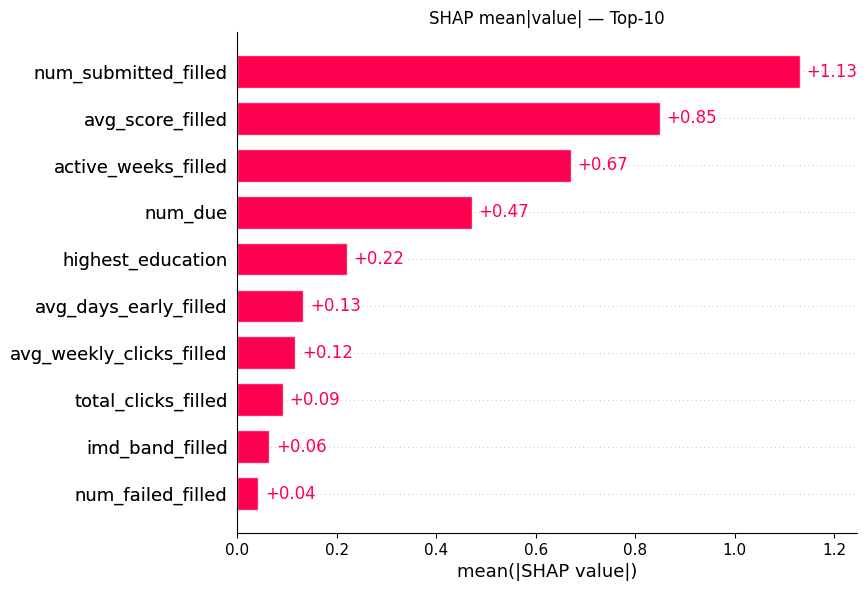


  SHAP — LightGBM  |  Top-5 (5 features)


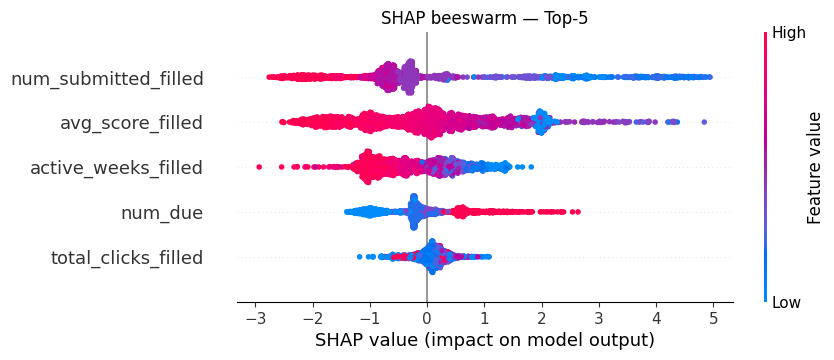

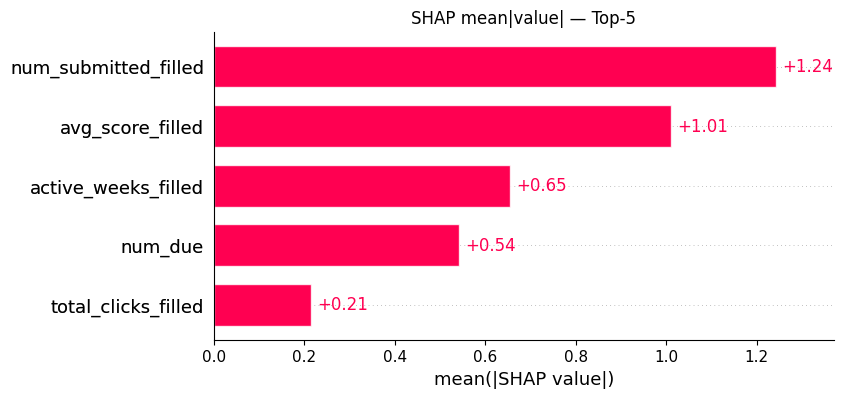

In [38]:
sv_full = shap_explain('Full (15)', trained_models,      X_test,      FEATURE_NAMES)
sv_t10  = shap_explain('Top-10',    trained_models_top,  X_test_top,  top10)
sv_t5   = shap_explain('Top-5',     trained_models_top5, X_test_top5, top5)

### Giải thích cục bộ — waterfall (vài ca cụ thể)

Waterfall cho thấy từng feature đẩy dự đoán của **một sinh viên** lên/xuống quanh giá trị nền (base value), trên model tốt nhất với bộ Full-feature.


  Waterfall — Đẩy mạnh về At-risk (mẫu #1612)


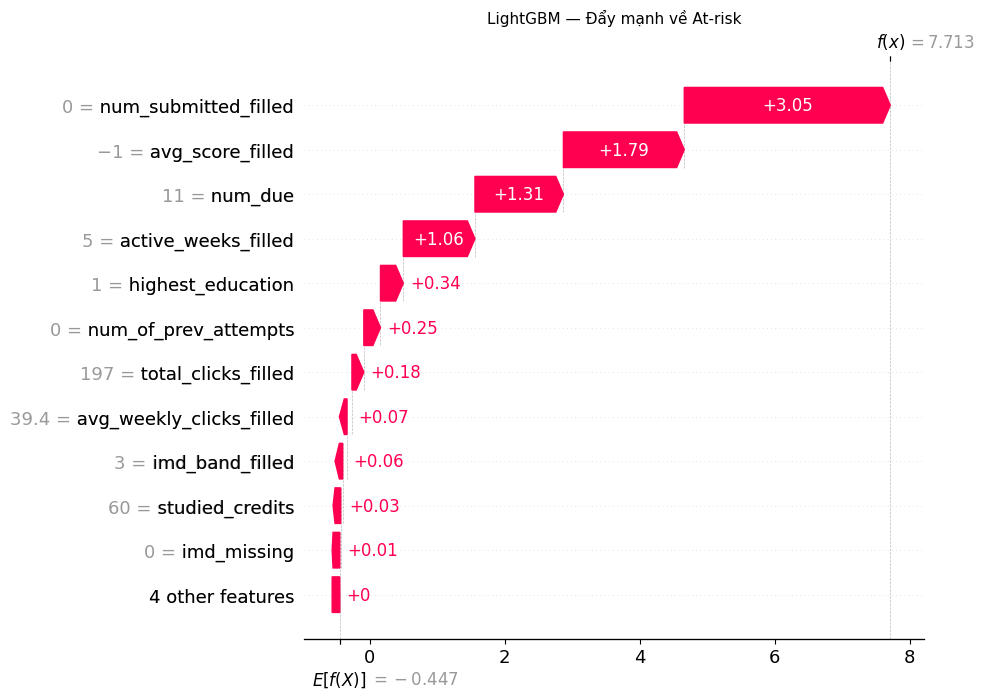


  Waterfall — Đẩy mạnh về Pass (mẫu #1237)


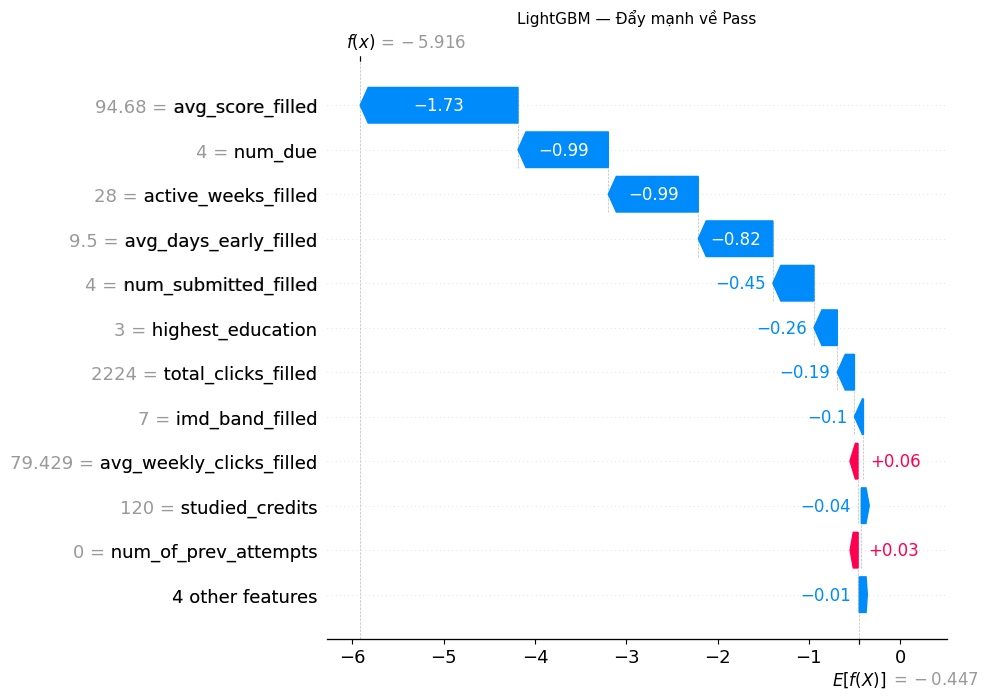

In [39]:
# Chọn 2 ca: 1 SHAP-sum cao nhất (đẩy mạnh về At-risk) và 1 thấp nhất (đẩy mạnh về Pass)
order = np.argsort(sv_full.values.sum(axis=1))
examples = {'Đẩy mạnh về At-risk': int(order[-1]), 'Đẩy mạnh về Pass': int(order[0])}

for label, idx in examples.items():
    print(f'\n{"="*55}\n  Waterfall — {label} (mẫu #{idx})\n{"="*55}')
    shap.plots.waterfall(sv_full[idx], max_display=12, show=False)
    plt.title(f'{BEST_MODEL} — {label}', fontsize=11)
    plt.show()